# Embedding + Classification Test

Scott Carnie-Bronca
07/08/2026

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from transformers import AutoModel, AutoTokenizer
from tqdm.auto import tqdm
import torch
import umap
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA

from transformers.utils import logging
logging.set_verbosity_error()
logging.disable_progress_bar()

## Load Data

In [3]:
SPLIT_SEEDS = ("2026", "2027", "2028", "2029", "2030")
train_data = []
validation_data = []
for seed in SPLIT_SEEDS:
    with open(f"../data/besstie/splits/seed_{seed}/train.csv", "r") as f:
        df = pd.read_csv(f)
        df["seed"] = seed
        train_data.append(df)

    with open(f"../data/besstie/splits/seed_{seed}/validation.csv", "r") as f:
        df = pd.read_csv(f)
        df["seed"] = seed
        validation_data.append(df)

In [4]:
df_train = pd.concat(train_data).reset_index(drop = True)
df_test = pd.concat(validation_data).reset_index(drop = True) # CHANGE FOR ACTUAL TEST DATA

display(df_train)
display(df_test)

,example_id,source,variety,text,sentiment,sarcasm,subset,original_split,seed
0,train_05395,reddit,en-UK,The man should be dismissed. Making a mockery ...,0,0,en_UK,train,2026
1,train_02887,google,en-UK,Good food in comfortable restaurant with a won...,1,0,en_UK,train,2026
2,train_04389,google,en-UK,"Decent food, decent size, fast and efficient s...",1,0,en_UK,train,2026
3,train_00626,google,en-AU,Food tastes good. Rang up for a delivery on a ...,0,0,en_AU,train,2026
4,train_05429,reddit,en-UK,And this is *their* estimates. There's a go...,0,0,en_UK,train,2026
...,...,...,...,...,...,...,...,...,...
23500,train_03844,google,en-UK,It was a quiet friendly place to have a game o...,1,0,en_UK,train,2030
23501,train_05386,reddit,en-UK,Its perspective. The poorest people in the UK ...,0,0,en_UK,train,2030
23502,train_00179,google,en-AU,Was n't impressed with the McFlurry or the sun...,0,0,en_AU,train,2030
23503,train_00895,google,en-AU,"It convenience over quality, it a great concep...",0,0,en_AU,train,2030


,example_id,source,variety,text,sentiment,sarcasm,subset,original_split,seed
0,train_00202,google,en-AU,"Great place, quiet, food was Lovely. Slow serv...",1,0,en_AU,train,2026
1,train_00605,google,en-AU,"Good breakfast, nice coffee but the toast was ...",1,0,en_AU,train,2026
2,train_02766,google,en-UK,Nice little restaurant. The place was very bus...,1,0,en_UK,train,2026
3,train_02266,reddit,en-AU,Go back to where ya came from lmao.,0,1,en_AU,train,2026
4,train_00906,google,en-AU,"When my mother and I walked in, the bar staff ...",0,1,en_AU,train,2026
...,...,...,...,...,...,...,...,...,...
4145,train_03551,google,en-UK,It's a lovely little neighborhood Costa shop b...,0,0,en_UK,train,2030
4146,train_03272,google,en-UK,Nice spot. Food is nice and very reasonably pr...,1,0,en_UK,train,2030
4147,train_01428,reddit,en-AU,My concept bar involves me walking to the loca...,0,1,en_AU,train,2030
4148,train_03882,google,en-UK,"Very disappointed with the whole experience, t...",0,0,en_UK,train,2030


## Embed Documents

In [5]:
def embed_docs(docs, embedding_model, batch_size = 50, max_tokens_in = 512):
    dev = "cuda:0" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(embedding_model, model_max_length = max_tokens_in)
    model = AutoModel.from_pretrained(embedding_model, dtype = torch.float16, output_loading_info = False).to(dev)
    docs_embeddings = np.ndarray(shape = (len(docs), model.config.hidden_size))
    for k in tqdm(range(0, len(docs), batch_size), desc = "Batches: ", disable = True):
        batch_docs = docs[k:(k+batch_size)] #get a batch of docs
        encoded_input = tokenizer(batch_docs, padding=True, truncation=True, return_tensors='pt').to(dev)
        with torch.no_grad():
            model_output = model(**encoded_input)
        #docs_embeddings[k:(k+batch_size)] = mean_pooling(model_output, encoded_input['attention_mask']).cpu()
        docs_embeddings[k:(k+batch_size)] = model_output.last_hidden_state[:,0].cpu()
    return docs_embeddings

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

In [6]:
doc_embeddings = embed_docs(df_train["text"].to_list(), embedding_model = 'FacebookAI/xlm-roberta-base', batch_size = 50)

In [7]:
df_train["embeddings_high"] = pd.Series([None] * len(df_train), dtype=object)
for seed in SPLIT_SEEDS:
    split_doc_embeddings = [x for k,x in enumerate(doc_embeddings) if df_train["seed"].values[k] == seed]
    split_indices = [k for k,x in enumerate(doc_embeddings) if df_train["seed"].values[k] == seed]

    highdim_embeddings = umap.UMAP(n_components = 20, n_neighbors = 50).fit_transform(split_doc_embeddings)
    plot_embeddings = umap.UMAP(n_components = 2, n_neighbors = 50).fit_transform(split_doc_embeddings)
    
    obj_col = np.empty(len(highdim_embeddings), dtype=object)
    for i, v in enumerate(highdim_embeddings):
        obj_col[i] = v.astype(np.float32)

    df_train.loc[split_indices, "embeddings_high"] = obj_col
    df_train.loc[split_indices, "embeddings_x"] = plot_embeddings[:,0]
    df_train.loc[split_indices, "embeddings_y"] = plot_embeddings[:,1]
df_train

KeyboardInterrupt: 

In [ ]:
len(df_train.loc[split_indices, "embeddings_high"])

4701

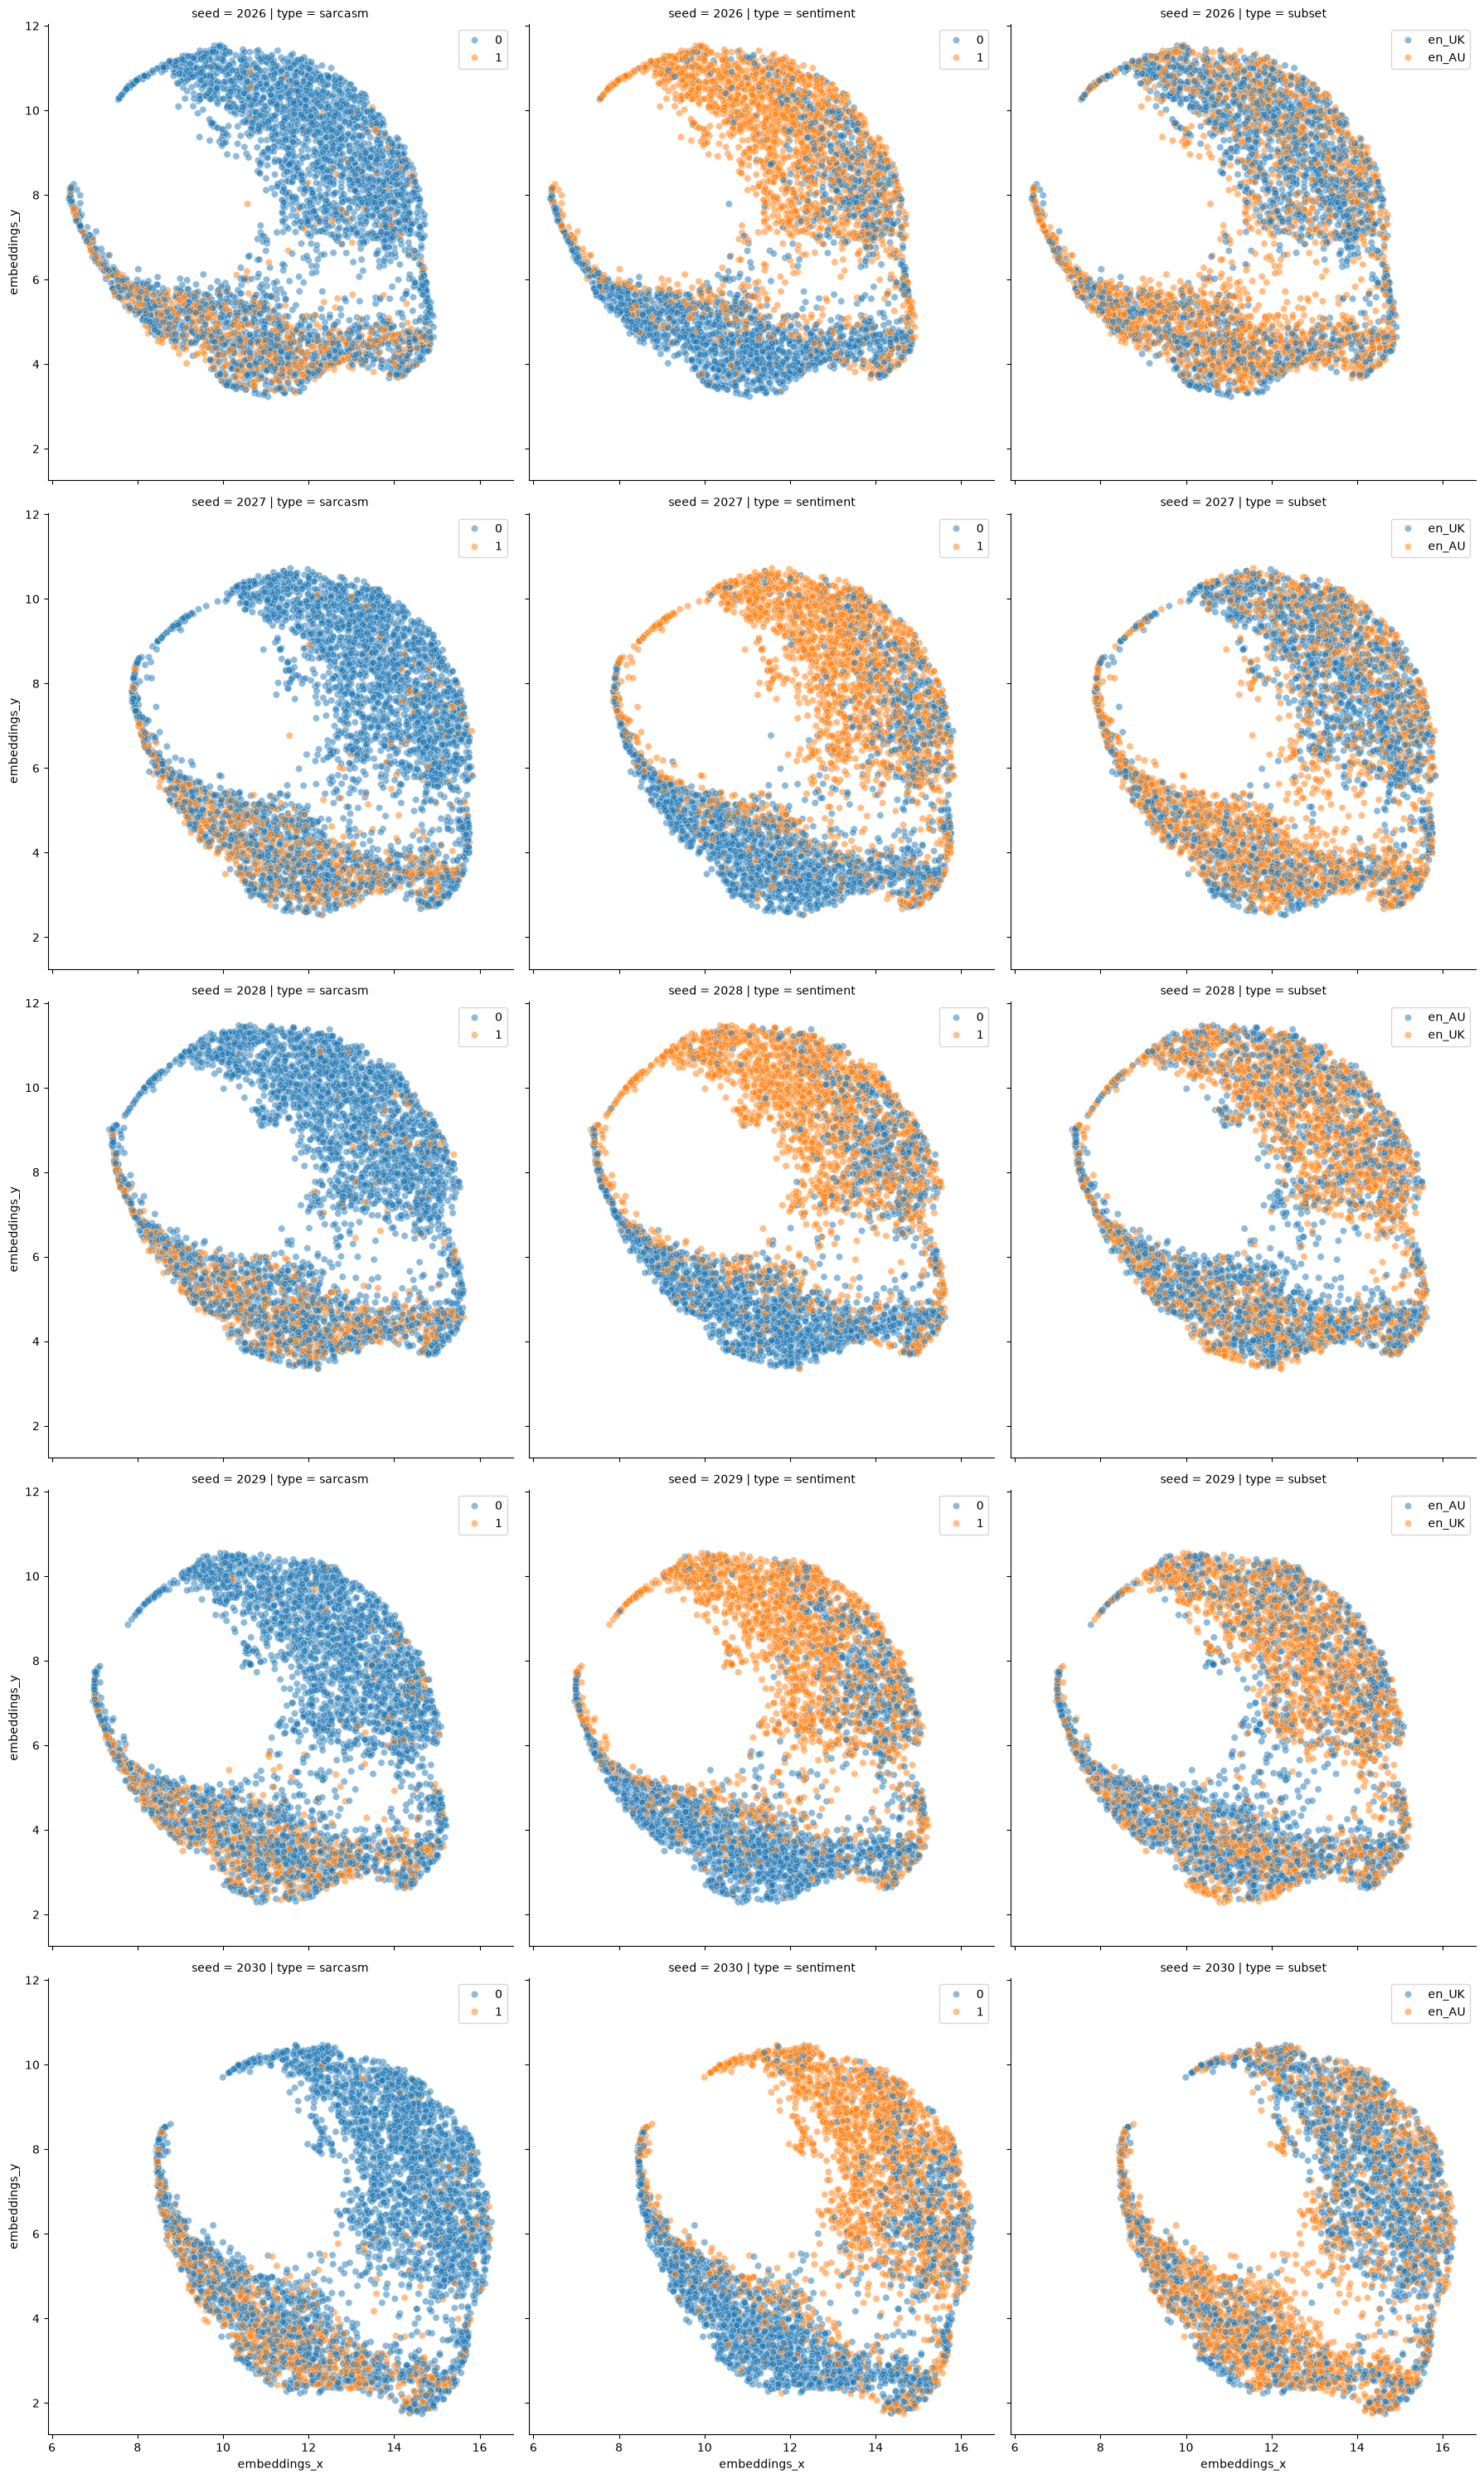

In [ ]:
df_train_long = df_train.melt(
    id_vars = [c for c in df_train.columns if c not in ['sarcasm','sentiment', 'subset']],
    value_vars = ['sarcasm','sentiment','subset'],
    var_name = "type",
    value_name = "score"
)

g = sns.FacetGrid(df_train_long, row = "seed", col = "type", height = 6)
g.map_dataframe(sns.scatterplot, x = "embeddings_x", y = "embeddings_y", hue = "score", alpha = 0.5)
for ax in g.axes.flat:
    ax.legend()

In [ ]:
df_train_long

,example_id,source,variety,text,original_split,seed,embeddings_high,embeddings_x,embeddings_y,type,score
0,train_05395,reddit,en-UK,The man should be dismissed. Making a mockery ...,train,2026,"[0.9436363, 6.8892765, 5.291845, 4.9754534, 4....",8.504392,4.797118,sarcasm,0
1,train_02887,google,en-UK,Good food in comfortable restaurant with a won...,train,2026,"[-0.7987078, 2.0102274, 8.760747, 3.7093186, 4...",10.612244,10.974309,sarcasm,0
2,train_04389,google,en-UK,"Decent food, decent size, fast and efficient s...",train,2026,"[-1.208522, 2.2338264, 8.930852, 3.554167, 4.9...",11.170847,10.953264,sarcasm,0
3,train_00626,google,en-AU,Food tastes good. Rang up for a delivery on a ...,train,2026,"[-0.76600605, 1.9688529, 8.889387, 3.6483479, ...",10.614131,11.205753,sarcasm,0
4,train_05429,reddit,en-UK,And this is *their* estimates. There's a go...,train,2026,"[0.5450402, 6.8304043, 5.5547576, 4.6977386, 4...",8.883135,4.902043,sarcasm,0
...,...,...,...,...,...,...,...,...,...,...,...
70510,train_03844,google,en-UK,It was a quiet friendly place to have a game o...,train,2030,"[-4.664569, 7.0365696, 8.092344, 4.0251126, 3....",15.366305,2.842621,subset,en_UK
70511,train_05386,reddit,en-UK,Its perspective. The poorest people in the UK ...,train,2030,"[-3.9925997, 6.9396806, 7.63088, 4.4368324, 3....",14.360876,2.753043,subset,en_UK
70512,train_00179,google,en-AU,Was n't impressed with the McFlurry or the sun...,train,2030,"[-3.581219, 4.4321923, 10.00419, 3.577516, 3.9...",15.627164,7.794702,subset,en_AU
70513,train_00895,google,en-AU,"It convenience over quality, it a great concep...",train,2030,"[-4.775875, 6.643773, 8.5399275, 3.899208, 3.7...",15.622705,3.473621,subset,en_AU


# Full Model + Testing

In [22]:
out = []
for embedding_model in ('FacebookAI/xlm-roberta-base', 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2', 'intfloat/multilingual-e5-base', 'sentence-transformers/all-MiniLM-L6-v2'):
    for k_neighbors in (2, 5, 10, 50, 100):
            print(f"================================================================\nembedding_model = {embedding_model} | k_neighbors = {k_neighbors}")
            for seed in ("2026", "2027"):
                print(f"----------------------------------------------------------------\nSeed: {seed}")
                df_train_seed_au = df_train[(df_train["seed"] == seed) & (df_train["variety"] == "en-AU")]
                df_train_seed_uk = df_train[(df_train["seed"] == seed) & (df_train["variety"] == "en-UK")]
                df_test_seed_au = df_test[(df_test["seed"] == seed) & (df_test["variety"] == "en-AU")]
                df_test_seed_uk = df_test[(df_test["seed"] == seed) & (df_test["variety"] == "en-UK")]


                train_embeddings_au = embed_docs(df_train_seed_au["text"].to_list(), embedding_model = embedding_model)
                train_embeddings_uk = embed_docs(df_train_seed_uk["text"].to_list(), embedding_model = embedding_model)
                test_embeddings_au = embed_docs(df_test_seed_au["text"].to_list(), embedding_model = embedding_model)
                test_embeddings_uk = embed_docs(df_test_seed_uk["text"].to_list(), embedding_model = embedding_model)

                dim_reduction_au = umap.UMAP(n_components = 200, n_neighbors = 20, metric = "cosine").fit(train_embeddings_au)
                dim_reduction_uk = umap.UMAP(n_components = 200, n_neighbors = 20, metric = "cosine").fit(train_embeddings_uk)

                train_reduced_au = dim_reduction_au.transform(train_embeddings_au)
                train_reduced_uk = dim_reduction_uk.transform(train_embeddings_uk)
                test_reduced_au = dim_reduction_au.transform(test_embeddings_au)
                test_reduced_uk = dim_reduction_uk.transform(test_embeddings_uk)

                # plot_reduction_au = PCA(n_components = 2).fit(train_reduced_au)
                # plot_reduction_uk = PCA(n_components = 2).fit(train_reduced_uk)

                # train_plot_au = plot_reduction_au.transform(train_reduced_au)
                # train_plot_uk = plot_reduction_uk.transform(train_reduced_uk)
                # test_plot_au = plot_reduction_au.transform(test_reduced_au)
                # test_plot_uk = plot_reduction_uk.transform(test_reduced_uk)


                classifier_sentiment_au = KNeighborsClassifier(n_neighbors = k_neighbors, metric = "cosine").fit(train_reduced_au, df_train_seed_au["sentiment"])
                classifier_sentiment_uk = KNeighborsClassifier(n_neighbors = k_neighbors, metric = "cosine").fit(train_reduced_uk, df_train_seed_uk["sentiment"])
                classifier_sarcasm_au = KNeighborsClassifier(n_neighbors = k_neighbors, metric = "cosine").fit(train_reduced_au, df_train_seed_au["sarcasm"])
                classifier_sarcasm_uk = KNeighborsClassifier(n_neighbors = k_neighbors, metric = "cosine").fit(train_reduced_uk, df_train_seed_uk["sarcasm"])
                
                pred_sentiment_au = classifier_sarcasm_au.predict(test_reduced_au)
                pred_sentiment_uk = classifier_sarcasm_uk.predict(test_reduced_uk)
                pred_sarcasm_au = classifier_sarcasm_au.predict(test_reduced_au)
                pred_sarcasm_uk = classifier_sarcasm_uk.predict(test_reduced_uk)

                f1_sentiment_au = f1_score(df_test_seed_au["sentiment"], pred_sentiment_au, average = "macro")
                f1_sentiment_uk = f1_score(df_test_seed_uk["sentiment"], pred_sentiment_uk, average = "macro")
                f1_sarcasm_au = f1_score(df_test_seed_au["sarcasm"], pred_sarcasm_au, average = "macro")
                f1_sarcasm_uk = f1_score(df_test_seed_uk["sarcasm"], pred_sarcasm_uk, average = "macro")

                print(f"Separate model f1 scores (au, uk): Sentiment = ({f1_sentiment_au}, {f1_sentiment_uk}) | Sarcasm = ({f1_sarcasm_au}, {f1_sarcasm_uk})")
                print(f"ALTA score: {0.5*(np.min((f1_sentiment_au, f1_sentiment_uk)) + np.min((f1_sarcasm_au, f1_sarcasm_uk)))}\n")
                classifier_joint_au = KNeighborsClassifier(n_neighbors = k_neighbors, metric = "cosine").fit(train_reduced_au, 2*df_train_seed_au["sarcasm"] + df_train_seed_au["sentiment"])
                classifier_joint_uk = KNeighborsClassifier(n_neighbors = k_neighbors, metric = "cosine").fit(train_reduced_uk, 2*df_train_seed_uk["sarcasm"] + df_train_seed_uk["sentiment"])
                pred_joint_au = classifier_joint_au.predict(test_reduced_au)
                pred_joint_uk = classifier_joint_uk.predict(test_reduced_uk)
                pred_jsentiment_au = pred_joint_au % 2
                pred_jsentiment_uk = pred_joint_uk % 2
                pred_jsarcasm_au = (pred_joint_au - (pred_joint_au % 2))/2
                pred_jsarcasm_uk = (pred_joint_uk - (pred_joint_uk % 2))/2

                f1_jsentiment_au = f1_score(df_test_seed_au["sentiment"], pred_jsentiment_au, average = "macro")
                f1_jsentiment_uk = f1_score(df_test_seed_uk["sentiment"], pred_jsentiment_uk, average = "macro")
                f1_jsarcasm_au = f1_score(df_test_seed_au["sarcasm"], pred_jsarcasm_au, average = "macro")
                f1_jsarcasm_uk = f1_score(df_test_seed_uk["sarcasm"], pred_jsarcasm_uk, average = "macro")
                
                print(f"Joint model f1 scores (au, uk): Sentiment = ({f1_jsentiment_au}, {f1_jsentiment_uk}) | Sarcasm = ({f1_jsarcasm_au}, {f1_jsarcasm_uk})")
                print(f"ALTA score: {0.5*(np.min((f1_jsentiment_au, f1_jsentiment_uk)) + np.min((f1_jsarcasm_au, f1_jsarcasm_uk)))}\n")

                out.append(pd.DataFrame({
                     "seed": seed,
                     "embedding_model": embedding_model,
                     "k_neighbours": k_neighbors,
                     "model_type": ["separate", "joint"],
                     "f1_sent_au": [f1_sentiment_au, f1_jsentiment_au],
                     "f1_sent_uk": [f1_sentiment_uk, f1_jsentiment_uk],
                     "f1_sarc_au": [f1_sarcasm_au, f1_jsarcasm_au],
                     "f1_sarc_uk": [f1_sarcasm_uk, f1_jsarcasm_uk],
                     "alta_score": [0.5*(np.min((f1_sentiment_au, f1_sentiment_uk)) + np.min((f1_sarcasm_au, f1_sarcasm_uk))), 0.5*(np.min((f1_jsentiment_au, f1_jsentiment_uk)) + np.min((f1_jsarcasm_au, f1_jsarcasm_uk)))]
                }))

embedding_model = FacebookAI/xlm-roberta-base | k_neighbors = 2
----------------------------------------------------------------
Seed: 2026
Separate model f1 scores (au, uk): Sentiment = (0.326125707199876, 0.31442463533225284) | Sarcasm = (0.5646307798481711, 0.5257991213452508)
ALTA score: 0.4201118783387518

Joint model f1 scores (au, uk): Sentiment = (0.7808614782183064, 0.7845617412815591) | Sarcasm = (0.5646307798481711, 0.5257991213452508)
ALTA score: 0.6533302997817786

----------------------------------------------------------------
Seed: 2027
Separate model f1 scores (au, uk): Sentiment = (0.31899606299212596, 0.3170139278894754) | Sarcasm = (0.5697933227344992, 0.5467288366300791)
ALTA score: 0.4318713822597773

Joint model f1 scores (au, uk): Sentiment = (0.718048128342246, 0.7478744939271256) | Sarcasm = (0.5697933227344992, 0.5467288366300791)
ALTA score: 0.6323884824861625

embedding_model = FacebookAI/xlm-roberta-base | k_neighbors = 5
----------------------------------

In [27]:
res = pd.concat(out, ignore_index = True)
res

,seed,embedding_model,k_neighbours,model_type,f1_sent_au,f1_sent_uk,f1_sarc_au,f1_sarc_uk,alta_score
0,2026,FacebookAI/xlm-roberta-base,2,separate,0.326126,0.314425,0.564631,0.525799,0.420112
1,2026,FacebookAI/xlm-roberta-base,2,joint,0.780861,0.784562,0.564631,0.525799,0.653330
2,2027,FacebookAI/xlm-roberta-base,2,separate,0.318996,0.317014,0.569793,0.546729,0.431871
3,2027,FacebookAI/xlm-roberta-base,2,joint,0.718048,0.747874,0.569793,0.546729,0.632388
4,2026,FacebookAI/xlm-roberta-base,5,separate,0.320989,0.310123,0.624054,0.511106,0.410614
...,...,...,...,...,...,...,...,...,...
75,2027,sentence-transformers/all-MiniLM-L6-v2,50,joint,0.680487,0.743667,0.653491,0.480344,0.580415
76,2026,sentence-transformers/all-MiniLM-L6-v2,100,separate,0.320477,0.323200,0.591921,0.479705,0.400091
77,2026,sentence-transformers/all-MiniLM-L6-v2,100,joint,0.681492,0.760312,0.623378,0.479705,0.580599
78,2027,sentence-transformers/all-MiniLM-L6-v2,100,separate,0.309914,0.323200,0.588220,0.480344,0.395129


In [30]:
scores = res.groupby(["embedding_model", "k_neighbours", "model_type"], as_index = False).agg(
    alta_score = pd.NamedAgg("alta_score", "mean")
)

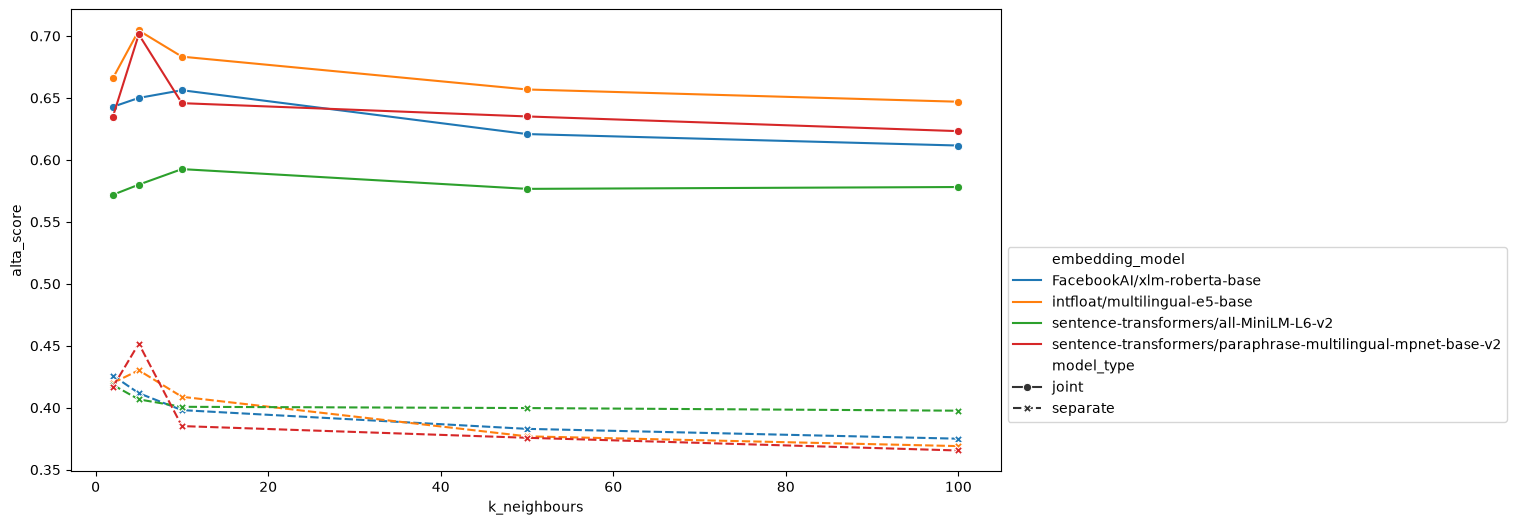

In [ ]:
plt.figure(figsize = (12, 6))
ax = sns.lineplot(scores, x = "k_neighbours", y = "alta_score", hue = "embedding_model", style = "model_type", markers = True)
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1, 0.5))